# EDA: Eksplorasi Data Komentar Judol
Tujuan: Memvalidasi hipotesa tentang perbedaan karakteristik komentar judol dan bukan judol.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

df = pd.read_csv('../Dataset/dataset_clean_final.csv')
df = df.dropna(subset=['text'])
print(f"Total data: {len(df)}")

Total data: 70379


## 1. Distribusi Label

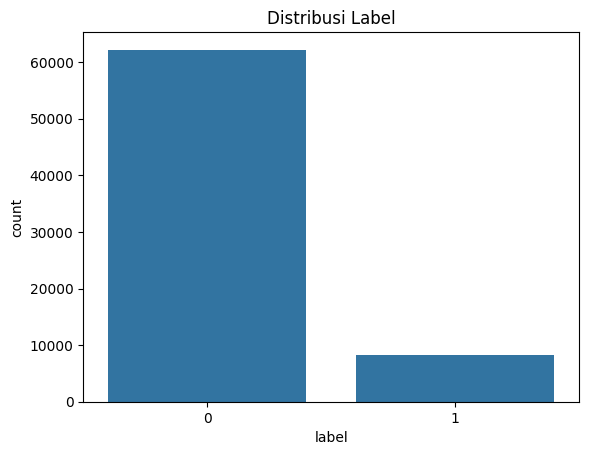

label
0    0.883815
1    0.116185
Name: proportion, dtype: float64


In [2]:
sns.countplot(x='label', data=df)
plt.title('Distribusi Label')
plt.show()
print(df['label'].value_counts(normalize=True))

## 2. Hipotesa Panjang Teks

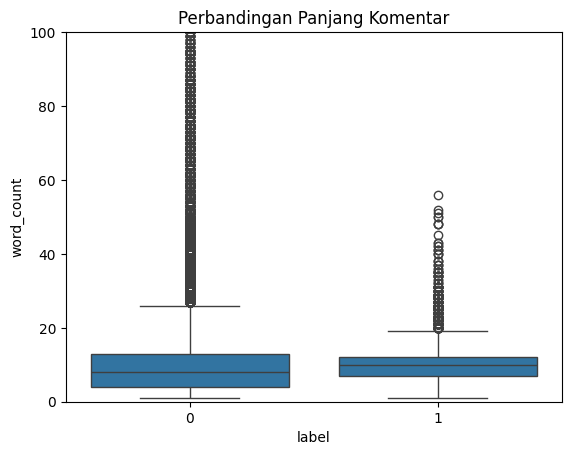

         count       mean        std  min  25%   50%   75%    max
label                                                            
0      62202.0  11.465982  16.962575  1.0  4.0   8.0  13.0  945.0
1       8177.0  10.304023   5.045393  1.0  7.0  10.0  12.0   56.0


In [3]:
df['word_count'] = df['text'].str.split().str.len()
sns.boxplot(x='label', y='word_count', data=df)
plt.title('Perbandingan Panjang Komentar')
plt.ylim(0, 100) # Fokus pada 100 kata pertama
plt.show()
print(df.groupby('label')['word_count'].describe())

## 3. Top Keywords Judol

In [4]:
def get_top_n_words(corpus, n=20):
    words = ' '.join(corpus).split()
    return Counter(words).most_common(n)

judol_words = get_top_n_words(df[df['label']==1]['text'])
normal_words = get_top_n_words(df[df['label']==0]['text'])

print("Top Keywords Judol:", judol_words)
print("Top Keywords Normal:", normal_words)

Top Keywords Judol: [('di', 2165), ('alexis17', 1217), ('bikin', 1172), ('banget', 1107), ('red_heart', 1078), ('yang', 987), ('main', 932), ('saya', 914), ('ini', 875), ('dan', 825), ('kamu', 772), ('gak', 738), ('8', 626), ('sudah', 538), ('star', 517), ('7', 513), ('pulauwin', 442), ('ada', 440), ('fire', 437), ('sih', 427)]
Top Keywords Normal: [('face_with_tears_of_joy', 15362), ('yang', 12248), ('di', 10351), ('dan', 7114), ('ini', 6851), ('saya', 6716), ('bang', 6525), (':', 5659), ('nya', 5496), ('red_heart', 4739), ('kalau', 4685), ('itu', 4681), ('ada', 4659), ('saja', 4409), ('iya', 4236), ('kamu', 4192), ('bisa', 4162), ('sama', 4071), ('sudah', 3696), ('lagi', 3635)]
